Slope: 2.152450090744102
Intercept: -1.0435571687840337

Actual Power: [21 10 29]
Predicted Power: [20.48094374  9.71869328 29.0907441 ]

Mean Squared Error: 0.11892912078682315
R2 Score: 0.9980396298771402

Voltage: 16 V
Predicted Power: 33.3956442831216 W


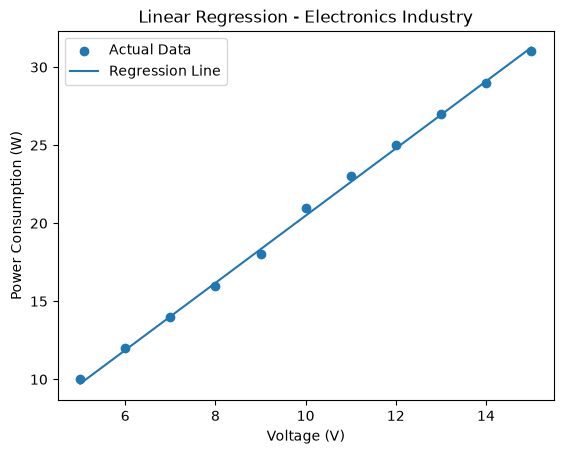

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

# 1. Sample electronics data
# Voltage (V)
X = np.array([
    5, 6, 7, 8, 9, 10,
    11, 12, 13, 14, 15
]).reshape(-1, 1)

# Power consumption (Watts)
y = np.array([
    10, 12, 14, 16, 18, 21,
    23, 25, 27, 29, 31
])

# 2. Split data into training and testing data
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

# 3. Create Linear Regression model
model = LinearRegression()

# 4. Train the model
model.fit(X_train, y_train)

# 5. Make predictions
y_pred = model.predict(X_test)

# 6. Print model information
print("Slope:", model.coef_[0])
print("Intercept:", model.intercept_)

print("\nActual Power:", y_test)
print("Predicted Power:", y_pred)

# 7. Evaluate the model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("\nMean Squared Error:", mse)
print("R2 Score:", r2)

# 8. Predict power consumption for a new voltage
new_voltage = np.array([[16]])

predicted_power = model.predict(new_voltage)

print("\nVoltage:", new_voltage[0][0], "V")
print("Predicted Power:", predicted_power[0], "W")

# 9. Visualize the regression line
plt.scatter(X, y, label="Actual Data")
plt.plot(X, model.predict(X), label="Regression Line")

plt.xlabel("Voltage (V)")
plt.ylabel("Power Consumption (W)")
plt.title("Linear Regression - Electronics Industry")
plt.legend()
plt.show()

Dataset shape: (62, 10)
                         movie_title mcu_phase release_date  tomato_meter  \
0                           Iron Man   Phase 1   2008-05-02            94   
1                The Incredible Hulk   Phase 1   2008-06-13            67   
2                         Iron Man 2   Phase 1   2010-05-07            72   
3                               Thor   Phase 1   2011-05-06            77   
4  Captain America The First Avenger   Phase 1   2011-07-22            80   

   audience_score  movie_duration  production_budget  opening_weekend  \
0              91           126.0        140000000.0      102118668.0   
1              70           112.0        137500000.0       55414050.0   
2              71           124.0        200000000.0      128122480.0   
3              76           114.0        150000000.0       65723338.0   
4              75           124.0        140000000.0       65058524.0   

   domestic_box_office  worldwide_box_office  
0          319034126.0     

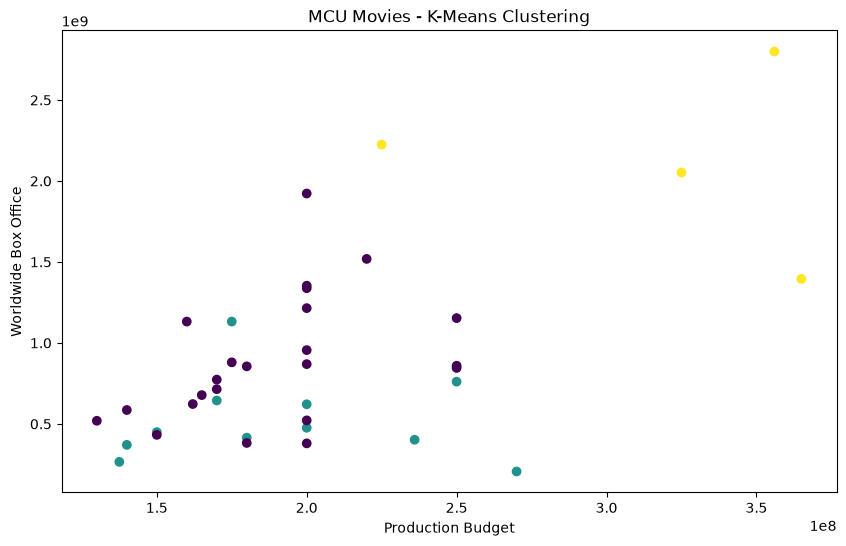

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# 1. Load the dataset
df = pd.read_csv("mcu.csv")

print("Dataset shape:", df.shape)
print(df.head())

# 2. Select features for clustering
X = df[
    [
        "tomato_meter",
        "audience_score",
        "production_budget",
        "worldwide_box_office"
    ]
]

# 3. Handle missing values
X = X.fillna(X.mean())

# 4. Scale the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 5. Create K-Means model
kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

# 6. Train the model
kmeans.fit(X_scaled)

# 7. Get cluster labels
df["cluster"] = kmeans.labels_

# 8. Display movies with their clusters
print("\nMovies and their clusters:")
print(df[["movie_title", "tomato_meter",
          "audience_score", "production_budget",
          "worldwide_box_office", "cluster"]].to_string(index=False))

# 9. Count movies in each cluster
print("\nNumber of movies in each cluster:")
print(df["cluster"].value_counts().sort_index())

# 10. Visualize clusters
plt.figure(figsize=(10, 6))

plt.scatter(
    df["production_budget"],
    df["worldwide_box_office"],
    c=df["cluster"]
)

plt.xlabel("Production Budget")
plt.ylabel("Worldwide Box Office")
plt.title("MCU Movies - K-Means Clustering")

plt.show()